> **Archive du TIPE (2024-25).** Tracé des courbes de convergence / temps et des courbes de loss. Les fichiers lus (`log_segment_times.txt`, `losses.csv`) sont maintenant dans `results/logs/`.

(50, 100, 500, 1000, 2500, 5000, 10000, 15000, 20000, 30000, 40000, 50000, 75000, 100000) (1.433, 1.4826, 2.6211, 3.9098, 7.1399, 11.4478, 19.537, 27.399, 34.0163, 46.5129, 61.0582, 71.4363, 102.7788, 123.4915)


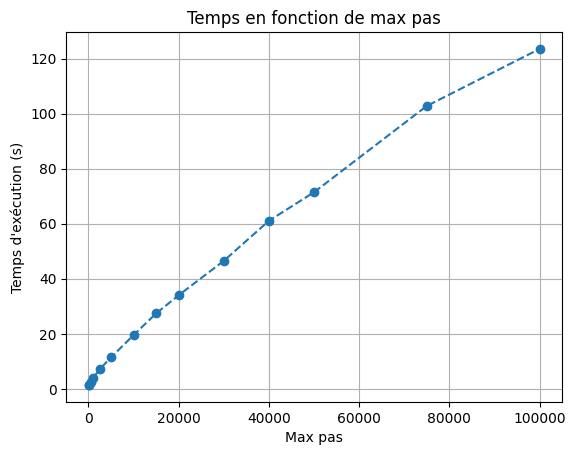

In [45]:
import matplotlib.pyplot as plt

# Lecture du fichier
with open("log_segment_times.txt", "r") as f:
    lines = f.readlines()

x = []  # max marches
y = []  # temps

for line in lines:
    try:
        parts = line.strip().split("|")
        # Exemple de parts :
        # ['2025-06-04T21:49:31.254039 ',
        #  ' Image: /home/... ',
        #  ' Max marches : 1000 Nb convergentes : 62576 ',
        #  ' Time: 3.9098 seconds']

        # Extraction du paramètre "Max marches"
        marches_part = parts[2]
        marches_str = marches_part.split("Max marches :")[1].split("Nb convergentes")[0].strip()
        max_marches = int(marches_str)

        # Extraction du temps
        time_part = parts[3]
        time_str = time_part.split("Time:")[1].strip().split()[0]
        time_val = float(time_str)

        x.append(max_marches)
        y.append(time_val)

    except Exception as e:
        print(f"Erreur sur la ligne : {line}")
        print(e)


x, y = zip(*sorted(zip(x, y)))

print(x,y)

# Tracé
plt.plot(x, y, marker="o", linestyle="--")
plt.xlabel("Max pas")
plt.ylabel("Temps d'exécution (s)")
plt.title("Temps en fonction de max pas")
plt.grid(True)
# Sauvegarde dans un fichier PNG
plt.savefig("courbe_temps_vs_max_pas.png", dpi=300, bbox_inches="tight")

# Affichage à l'écran
plt.show()

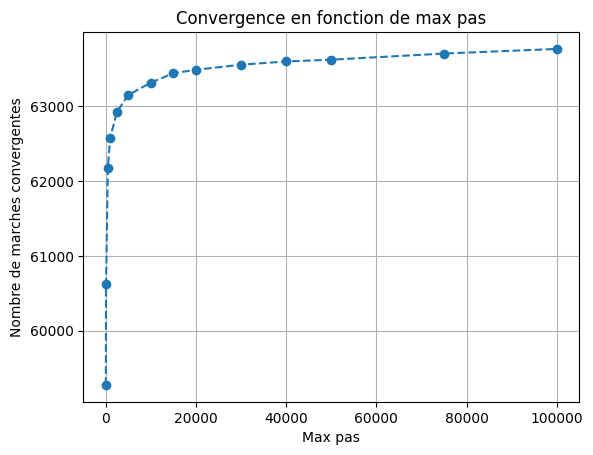

In [49]:
import matplotlib.pyplot as plt

x = []  # max marches
y = []  # nb convergentes

with open("log_segment_times.txt", "r") as f:
    lines = f.readlines()

for line in lines:
    try:
        parts = line.strip().split("|")

        # Exemple de parts[2] :
        # ' Max marches : 1000 Nb convergentes : 62576 '
        marches_part = parts[2]

        # Extraction des deux valeurs avec split
        max_marches = int(marches_part.split("Max marches :")[1].split("Nb convergentes")[0].strip())
        nb_convergentes = int(marches_part.split("Nb convergentes :")[1].strip())

        x.append(max_marches)
        y.append(nb_convergentes)

    except Exception as e:
        print(f"Erreur sur la ligne : {line}")
        print(e)

# Trier pour affichage propre
x, y = zip(*sorted(zip(x, y)))

# Tracé
plt.plot(x, y, marker="o", linestyle="--")
plt.xlabel("Max pas")
plt.ylabel("Nombre de marches convergentes")
plt.title("Convergence en fonction de max pas")
plt.grid(True)
plt.savefig("courbe_convergence_vs_max_pas.png", dpi=300, bbox_inches="tight")
plt.show()

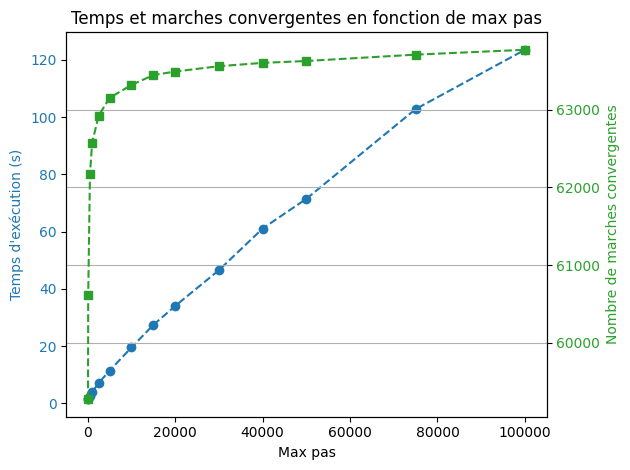

In [53]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

x = []
temps = []
nb_conv = []

with open("log_segment_times.txt", "r") as f:
    lines = f.readlines()

for line in lines:
    try:
        parts = line.strip().split("|")
        marches_part = parts[2]
        time_part = parts[3]

        max_marches = int(marches_part.split("Max marches :")[1].split("Nb convergentes")[0].strip())
        convergentes = int(marches_part.split("Nb convergentes :")[1].strip())
        time_val = float(time_part.split("Time:")[1].strip().split()[0])

        x.append(max_marches)
        nb_conv.append(convergentes)
        temps.append(time_val)

    except Exception as e:
        print(f"Erreur ligne : {line}")
        print(e)

# Tri par abscisse croissante
x, temps, nb_conv = zip(*sorted(zip(x, temps, nb_conv)))

# Tracé avec deux axes y
fig, ax1 = plt.subplots()

# Axe gauche : temps
ax1.plot(x, temps, "o--", color="tab:blue", label="Temps (s)")
ax1.set_xlabel("Max pas")
ax1.set_ylabel("Temps d'exécution (s)", color="tab:blue")
ax1.tick_params(axis='y', labelcolor="tab:blue")

# Axe droit : nb convergentes
ax2 = ax1.twinx()
ax2.plot(x, nb_conv, "s--", color="tab:green", label="Nb convergentes")
ax2.set_ylabel("Nombre de marches convergentes", color="tab:green")
ax2.tick_params(axis='y', labelcolor="tab:green")

# Titre + grille
plt.title("Temps et marches convergentes en fonction de max pas")
fig.tight_layout()
plt.grid(True)

# Sauvegarde + affichage
plt.savefig("figure_temps_nbconvergentes.png", dpi=300)
plt.show()

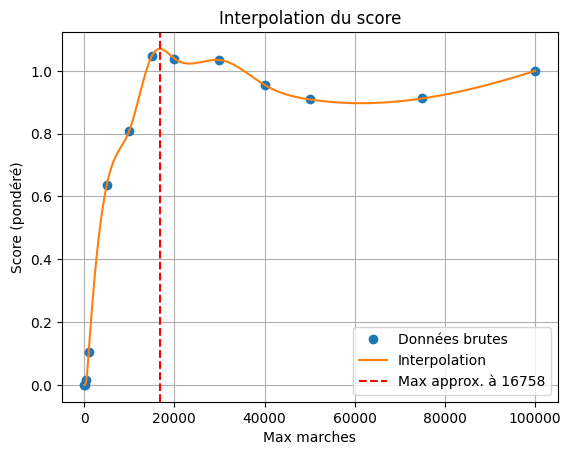

🔍 Optimum estimé : max_marches = 16758.36, score ≈ 1.0698


In [38]:
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import numpy as np


x = []
temps = []
nb_conv = []

with open("log_segment_times.txt", "r") as f:
    lines = f.readlines()

for line in lines:
    try:
        parts = line.strip().split("|")

        # Extraction
        marches_part = parts[2]
        time_part = parts[3]

        max_marches = int(marches_part.split("Max marches :")[1].split("Nb convergentes")[0].strip())
        convergentes = int(marches_part.split("Nb convergentes :")[1].strip())
        time_val = float(time_part.split("Time:")[1].strip().split()[0])

        x.append(max_marches)
        nb_conv.append(convergentes)
        temps.append(time_val)

    except Exception as e:
        print(f"Erreur ligne : {line}")
        print(e)

# Trier par abscisse
x, temps, nb_conv = zip(*sorted(zip(x, temps, nb_conv)))

# Normalisation [0, 1] pour score comparatif
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()
# Normalisation
temps_norm = scaler.fit_transform(np.array(temps).reshape(-1, 1)).flatten()
nb_conv_norm = scaler.fit_transform(np.array(nb_conv).reshape(-1, 1)).flatten()

# Poids d’importance sur nb_convergentes
alpha = 20 # ou essaie 2, 4, etc.
score = (nb_conv_norm ** alpha) / (temps_norm + 1e-6)

# Interpolation (cubic = interpolation de type spline)
interp_func = interp1d(x, score, kind="cubic")

# Abscisses interpolées très fines
x_interp = np.linspace(min(x), max(x), 1000)
score_interp = interp_func(x_interp)

# Trouver l’optimum
best_idx = np.argmax(score_interp)
best_x = x_interp[best_idx]
best_score = score_interp[best_idx]

# Affichage
plt.plot(x, score, "o", label="Données brutes")
plt.plot(x_interp, score_interp, "-", label="Interpolation")
plt.axvline(best_x, color="red", linestyle="--", label=f"Max approx. à {int(best_x)}")
plt.xlabel("Max marches")
plt.ylabel("Score (pondéré)")
plt.title("Interpolation du score")
plt.legend()
plt.grid(True)
plt.savefig("score_interpolé.png", dpi=300)
plt.show()

print(f"🔍 Optimum estimé : max_marches = {best_x:.2f}, score ≈ {best_score:.4f}")

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_losses_cumulatives(csv_path="losses.csv", output_dir="plots", filename="loss_cumulative.png"):
    df = pd.read_csv(csv_path)

    # Calcul de l'epoch cumulée
    df["Global Epoch"] = (df["Session"] - 1) * 50 + df["Epoch"]

    # Créer le dossier s'il n'existe pas
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, filename)

    # Tracé
    plt.figure(figsize=(10, 5))
    plt.plot(df["Global Epoch"], df["Train Loss"], label="Train Loss", marker='o')
    plt.plot(df["Global Epoch"], df["Validation Loss"], label="Validation Loss", marker='x')
    plt.xlabel("Époch cumulée")
    plt.ylabel("Loss")
    plt.title("Évolution cumulée des pertes (toutes sessions)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    # Sauvegarde du graphique
    plt.savefig(output_path)
    plt.close()
    print(f"✅ Graphe sauvegardé dans {output_path}")

In [5]:
plot_losses_cumulatives("losses_not_shuffled.csv")

✅ Graphe sauvegardé dans plots/loss_cumulative.png
